In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("somesh24/spambase")

print("Path to dataset files:", path)
# path = "/kaggle/input/predict-loan-amount-data"

Path to dataset files: /kaggle/input/spambase


# IMPORT FUNCTIONS

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Binarizer
import time
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# CONFIGURATIONS

In [ ]:
DATASET_PATH = path
TRAIN_FILE = "spambase_csv.csv"

# Target variable
TARGET_COL = "class"

# Columns to drop
UNNECESSARY_COLS = []

# Categorical filling strategy
CATEGORICAL_FILL_MODE = "mode"

# Numerical fill defaults
NUMERIC_FILL_VALUES = {}

# Outlier threshold
OUTLIER_FILTER = {}

# Step 1: User selects the model type
option = int(input(
    "Choose the model:\n"
    "1. Gaussian NB\n"
    "2. Multinomial NB\n"
    "3. Bernoulli NB\n"
    "4. k-NN with KD Tree\n"
    "5. k-NN with Ball Tree\n"
    "6. k-NN varying k\n"
    "7. SVM (Linear)\n"
    "8. SVM (Polynomial)\n"
    "9. SVM (RBF)\n"
    "10. SVM (Sigmoid)\n"
))

# Step 2: Model and Param Grid Configurations
model_param_map = {
    1: {"model": GaussianNB(), "param_grid": {}},
    2: {"model": MultinomialNB(), "param_grid": {}},
    3: {"model": BernoulliNB(), "param_grid": {}},
    4: {"model": KNeighborsClassifier(algorithm="kd_tree"), "param_grid": {
        "n_neighbors": [1, 3, 5, 7]
    }},
    5: {"model": KNeighborsClassifier(algorithm="ball_tree"), "param_grid": {
        "n_neighbors": [1, 3, 5, 7]
    }},
    6: {"model": KNeighborsClassifier(), "param_grid": {
        "n_neighbors": [1, 3, 5, 7, 9],
        "algorithm": ["auto", "kd_tree", "ball_tree"]
    }},
    7: {"model": SVC(kernel="linear"), "param_grid": {
        "C": [0.1, 1, 10]
    }},
    8: {"model": SVC(kernel="poly"), "param_grid": {
        "C": [0.1, 1, 10],
        "degree": [2, 3, 4],
        "gamma": ["scale", "auto"]
    }},
    9: {"model": SVC(kernel="rbf"), "param_grid": {
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto"]
    }},
    10: {"model": SVC(kernel="sigmoid"), "param_grid": {
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto"]
    }},
}

if option not in model_param_map:
    raise ValueError("Invalid option selected!")

model_config = model_param_map[option]
base_model = model_config["model"]
param_grid = model_config["param_grid"]

Choose the model:
1. Gaussian NB
2. Multinomial NB
3. Bernoulli NB
4. k-NN with KD Tree
5. k-NN with Ball Tree
6. k-NN varying k
7. SVM (Linear)
8. SVM (Polynomial)
9. SVM (RBF)
10. SVM (Sigmoid)
9


# LOAD DATA

In [ ]:
df = pd.read_csv(f"{DATASET_PATH}/{TRAIN_FILE}")
print("Shape:", df.shape)

Shape: (4601, 58)


# REMOVE UNWANTED COLUMNS

In [ ]:
# if UNNECESSARY_COLS:
#     df.drop(columns=[col for col in UNNECESSARY_COLS if col in df.columns], inplace=True)

# FILL MISSING VALUES

In [ ]:
for col in df.columns:
  count = df[col].isna().sum()
  print(f"{col} -> {count} missing values")

# if NUMERIC_FILL_VALUES:
#   for col, val in NUMERIC_FILL_VALUES.items():
#       if col in df.columns:
#           if val == 'median':
#               df[col] = df[col].fillna(df[col].median())
#           elif val == 'mean':
#               df[col] = df[col].fillna(df[col].mean())
#           else:
#               df[col] = df[col].fillna(val)

# for col in df.select_dtypes(include=['int64', 'float64']):
#   if col in df.columns:
#     df[col] = df[col].fillna(df[col].median())

# for col in df.select_dtypes(include='object').columns:
#     if CATEGORICAL_FILL_MODE == "mode":
#         df[col] = df[col].fillna(df[col].mode()[0])
#     else:
#         df[col] = df[col].fillna("Unknown")

# df = df[~df[TARGET_COL].isna()]

word_freq_make -> 0 missing values
word_freq_address -> 0 missing values
word_freq_all -> 0 missing values
word_freq_3d -> 0 missing values
word_freq_our -> 0 missing values
word_freq_over -> 0 missing values
word_freq_remove -> 0 missing values
word_freq_internet -> 0 missing values
word_freq_order -> 0 missing values
word_freq_mail -> 0 missing values
word_freq_receive -> 0 missing values
word_freq_will -> 0 missing values
word_freq_people -> 0 missing values
word_freq_report -> 0 missing values
word_freq_addresses -> 0 missing values
word_freq_free -> 0 missing values
word_freq_business -> 0 missing values
word_freq_email -> 0 missing values
word_freq_you -> 0 missing values
word_freq_credit -> 0 missing values
word_freq_your -> 0 missing values
word_freq_font -> 0 missing values
word_freq_000 -> 0 missing values
word_freq_money -> 0 missing values
word_freq_hp -> 0 missing values
word_freq_hpl -> 0 missing values
word_freq_george -> 0 missing values
word_freq_650 -> 0 missing value

# CHECK AND REMOVE OUTLIERS

In [ ]:
# for col in df.select_dtypes(include=['int64', 'float64']).columns:
#     sns.histplot(df[col], kde=True)
#     plt.title(f"Distribution of {col}")
#     plt.show()

In [ ]:
# for col, threshold in OUTLIER_FILTER.items():
#     df = df[df[col] < threshold]

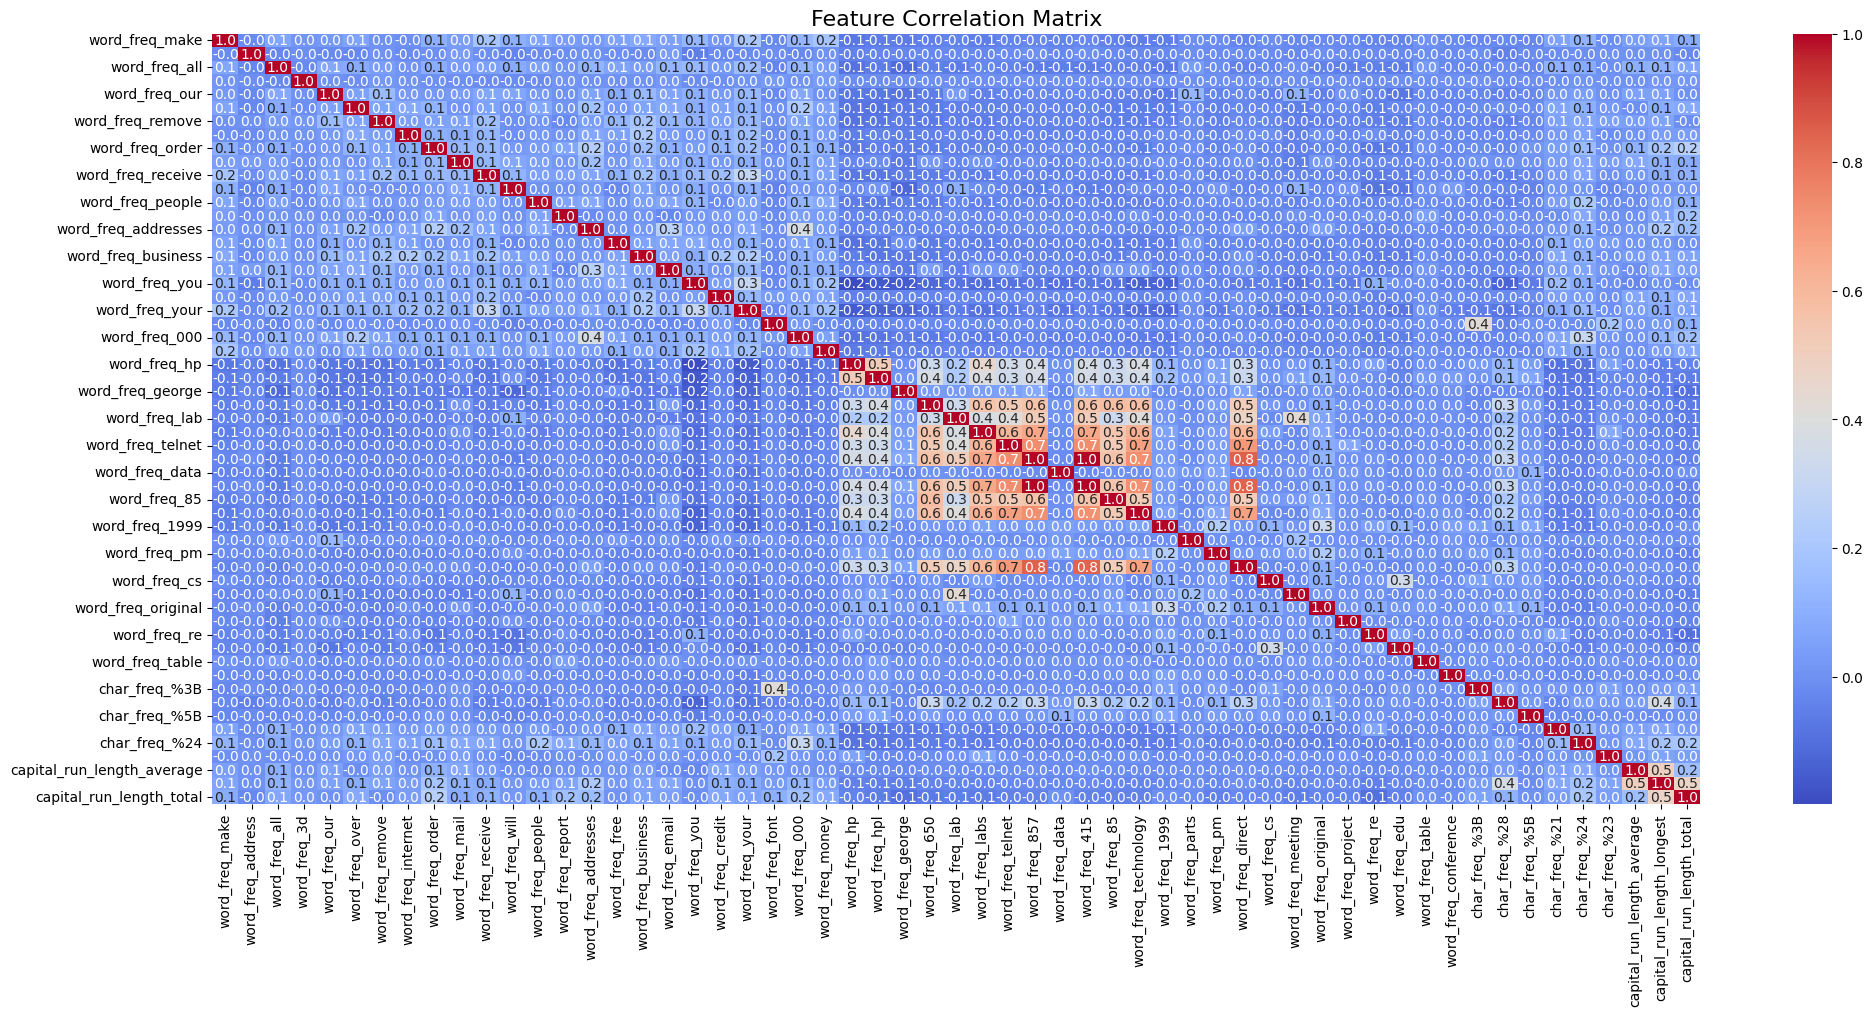

In [ ]:
corr = df.drop(columns=["class"]).corr()

# Plot heatmap
plt.figure(figsize=(24, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".1f", cbar=True)
plt.title("Feature Correlation Matrix", fontsize=16)
plt.show()

# ENCODE CATEGORICAL DATA

In [ ]:
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# STANDARDIZE CONTINUOUS DATA

In [ ]:
# # Get all numerical columns except the target
# numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# features_to_scale = [col for col in numerical_cols if col != TARGET_COL]

# # Apply model-specific preprocessing
# if option == 1:  # GaussianNB
#     scaler = StandardScaler()
#     df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# elif option in [2, 4, 5, 6, 7, 8, 9, 10]:  # MNB, k-NN, SVMs
#     scaler = MinMaxScaler()
#     df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# elif option == 3:  # BernoulliNB
#     binarizer = Binarizer(threshold=0.1)
#     df[features_to_scale] = binarizer.fit_transform(df[features_to_scale])

# else:
#     raise ValueError("Invalid option for preprocessing!")

# SPLITTING TO FEATURES AND TARGETS

In [ ]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Get all numerical columns except the target
features_to_scale = X_temp.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Apply model-specific preprocessing
if option == 1:  # GaussianNB
    scaler = StandardScaler()
    X_temp[features_to_scale] = scaler.fit_transform(X_temp[features_to_scale])

elif option in [2, 4, 5, 6, 7, 8, 9, 10]:  # MNB, k-NN, SVMs
    scaler = MinMaxScaler()
    X_temp[features_to_scale] = scaler.fit_transform(X_temp[features_to_scale])

elif option == 3:  # BernoulliNB
    binarizer = Binarizer(threshold=0.1)
    X_temp[features_to_scale] = binarizer.fit_transform(X_temp[features_to_scale])

else:
    raise ValueError("Invalid option for preprocessing!")

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# CROSS VALIDATION

In [ ]:
# Step 3: Use GridSearchCV to find best hyperparameters
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(estimator=base_model,
                    param_grid=param_grid,
                    scoring='accuracy',
                    cv=skf,
                    n_jobs=-1)
grid.fit(X_val, y_val)

print("✅ Best hyperparameters:", grid.best_params_)

best_model = grid.best_estimator_

# Step 4: Cross-validation metrics using best model
cv_metrics = {
    "Fold": [], "Accuracy": [], "Precision": [], "Recall": [], "F1": []
}

fold = 1
for train_idx, val_idx in skf.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    best_model.fit(X_train_fold, y_train_fold)
    y_pred = best_model.predict(X_val_fold)

    cv_metrics["Fold"].append(f"Fold {fold}")
    cv_metrics["Accuracy"].append(accuracy_score(y_val_fold, y_pred))
    cv_metrics["Precision"].append(precision_score(y_val_fold, y_pred, zero_division=0))
    cv_metrics["Recall"].append(recall_score(y_val_fold, y_pred))
    cv_metrics["F1"].append(f1_score(y_val_fold, y_pred))
    fold += 1

# Add average row
cv_metrics["Fold"].append("Average")
for metric in ["Accuracy", "Precision", "Recall", "F1"]:
    cv_metrics[metric].append(np.mean(cv_metrics[metric]))

print("\n📋 Cross-Validation Metrics:")
print(pd.DataFrame(cv_metrics))

✅ Best hyperparameters: {'C': 10, 'gamma': 'scale'}

📋 Cross-Validation Metrics:
      Fold  Accuracy  Precision    Recall        F1
0   Fold 1  0.900621   0.868217  0.881890  0.875000
1   Fold 2  0.937888   0.928000  0.913386  0.920635
2   Fold 3  0.916149   0.923729  0.858268  0.889796
3   Fold 4  0.953416   0.944444  0.937008  0.940711
4   Fold 5  0.925466   0.925000  0.880952  0.902439
5  Average  0.926708   0.917878  0.894301  0.905716


# Validation

In [ ]:
# Best model from GridSearchCV
best_model = grid.best_estimator_

# Measure training time
start_time = time.time()
best_model.fit(X_train, y_train)
training_duration = time.time() - start_time
print(f"\n⏱️ Model Training Time: {training_duration:.2f} seconds\n")


⏱️ Model Training Time: 0.10 seconds



In [ ]:
def evaluate_classification(name, y_true, y_pred):
    print(f"\n📊 {name} Metrics:")
    print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1-Score : {f1_score(y_true, y_pred):.4f}")

    if name == "Test":
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'{name} - Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()

In [ ]:
# Apply model-specific preprocessing
if option == 1:  # GaussianNB
    X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])

elif option in [2, 4, 5, 6, 7, 8, 9, 10]:  # MNB, k-NN, SVMs
    X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])

elif option == 3:  # BernoulliNB
    X_test[features_to_scale] = binarizer.transform(X_test[features_to_scale])


📊 Train Metrics:
  Accuracy : 0.9702
  Precision: 0.9772
  Recall   : 0.9464
  F1-Score : 0.9615

📊 Validation Metrics:
  Accuracy : 0.9143
  Precision: 0.9094
  Recall   : 0.8693
  F1-Score : 0.8889

📊 Test Metrics:
  Accuracy : 0.9160
  Precision: 0.9213
  Recall   : 0.8603
  F1-Score : 0.8897


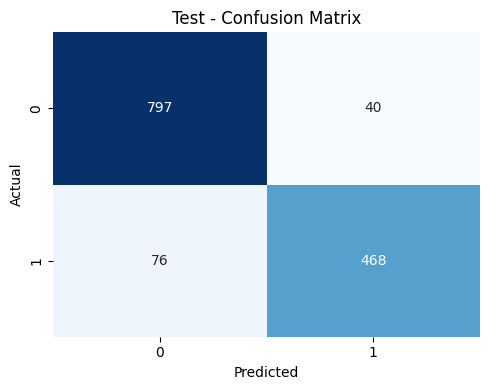

/tmp/ipython-input-1106873262.py:27: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


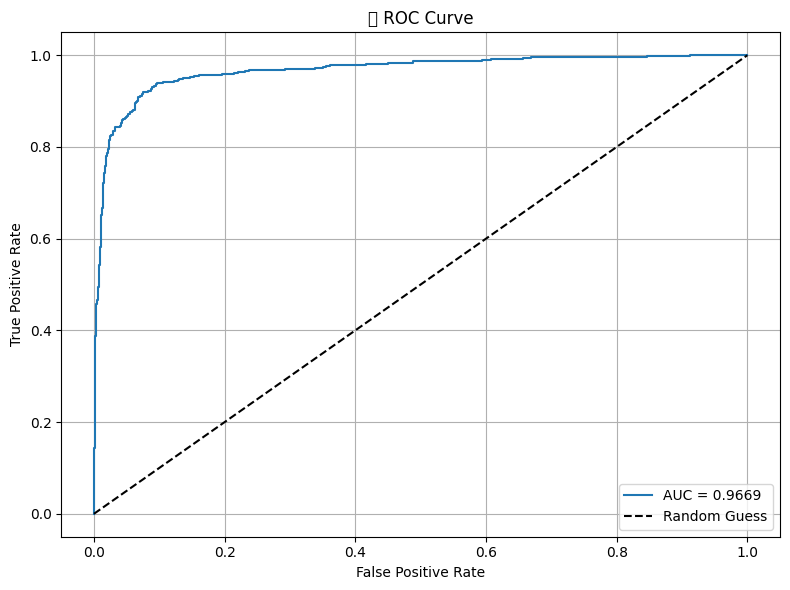

In [ ]:
for name, (X_split, y_split) in zip(["Train", "Validation", "Test"], [(X_train, y_train), (X_val, y_val), (X_test, y_test)]):
    y_pred = best_model.predict(X_split)
    evaluate_classification(name, y_split, y_pred)

    if name == "Test":
        # Check if model supports probabilities
        if hasattr(best_model, "predict_proba"):
            y_probs = best_model.predict_proba(X_split)[:, 1]
        elif hasattr(best_model, "decision_function"):
            y_probs = best_model.decision_function(X_split)
        else:
            print("Model does not support ROC plotting.")
            continue

        # Plot ROC Curve
        fpr, tpr, _ = roc_curve(y_split, y_probs)
        auc_score = roc_auc_score(y_split, y_probs)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
        plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("🔍 ROC Curve")
        plt.legend(loc="lower right")
        plt.grid()
        plt.tight_layout()
        plt.show()